# Import all needed Modules and set constants (copied from course)

## Sizes
64 was the base in the course. I want to go as low as 16 since at least humans can still recognize patterns in colored images with a size of 4 by 4 (Check out https://de.sporcle.com/games/ohicanchat/name-the-league-of-legends-characters-from-16-pixels if you know League of Legends and want a challenge) Since our AI has to work on grayscale (I think) this is a bit harsh, but maybe 16 by 16 will yield results.

In [19]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['dislike', 'fist', 'like', 'one', 'peace', 'stop']

# image size
# Use a broad array of selections
# Is 16 even viable? We  will find out!
# I really want to do 512 as well, but I will first see how long training takes on 256
IMG_SIZES = [8, 16, 32, 64, 128, 256, 512]

PATH = '../dataset_sample/'

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations (copied from course)


In [20]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing) (also copied from course and adjusted slightly to take size as an arg)

In [21]:
def preprocess_image(img, size):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, (size, size)) # Use this tuple directly to make it loopable better later
    return img_resized

## Load images and annotations. Taken from the course and then adjusted because we of course need 5 different lists this time

In [22]:
# We can use dicts and store lists using the size as a key
images = {} # stores actual image data
for size in IMG_SIZES:
    images[size] = []
labels = {} # stores labels (as integer - because this is what our network needs)
for size in IMG_SIZES:
    labels[size] = []
label_names = {} # maps label ints to their actual categories so we can understand predictions later
for size in IMG_SIZES:
    label_names[size] = []

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')

        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue

        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h

            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]

            # We need to repeat this part for every size this time unlike in the course where we only did it once
            for size in IMG_SIZES:

                preprocessed = preprocess_image(crop, size)

                # get the annotated hand's label
                # if we have not seen this label yet, add it to the list of labels
                label = annotation['labels'][i]
                if label == "no_gesture":
                    continue
                if label not in label_names[size]:
                    label_names[size].append(label)

                label_index = label_names[size].index(label)

                images[size].append(preprocessed)
                labels[size].append(label_index)

100%|██████████| 250/250 [00:08<00:00, 28.32it/s]


## split data set into train and test

x is for the actual data, y is for the label (this is convention). We copy this from the course and run it for each image size

In [23]:
X_train = {}
X_test = {}
y_train = {}
y_test = {}
for size in IMG_SIZES:
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(images[size], labels[size], test_size=0.2, random_state=42)
    X_train[size] = X_train_subset
    X_test[size] = X_test_subset
    y_train[size] = y_train_subset
    y_test[size] = y_test_subset


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

This is also copied from the course script and then adjusted to run 5 times

In [24]:
train_label = {}
test_label = {}

for size in IMG_SIZES:
    X_train[size] = np.array(X_train[size]).astype('float32')
    X_train[size] /= 255

    X_test[size] = np.array(X_test[size]).astype('float32')
    X_test[size] /= 255

    y_train_one_hot = to_categorical(y_train[size])
    y_test_one_hot = to_categorical(y_test[size])

    train_label[size] = y_train_one_hot
    test_label[size] = y_test_one_hot

    X_train[size] = X_train[size].reshape(-1, size, size, COLOR_CHANNELS)
    X_test[size] = X_test[size].reshape(-1, size, size, COLOR_CHANNELS)



## Adding a check if everything went right

In [25]:
for size in IMG_SIZES:
    print(
        size,
        X_train[size].shape,
        X_test[size].shape,
        train_label[size].shape,
        test_label[size].shape
    )

8 (1200, 8, 8, 3) (300, 8, 8, 3) (1200, 6) (300, 6)
16 (1200, 16, 16, 3) (300, 16, 16, 3) (1200, 6) (300, 6)
32 (1200, 32, 32, 3) (300, 32, 32, 3) (1200, 6) (300, 6)
64 (1200, 64, 64, 3) (300, 64, 64, 3) (1200, 6) (300, 6)
128 (1200, 128, 128, 3) (300, 128, 128, 3) (1200, 6) (300, 6)
256 (1200, 256, 256, 3) (300, 256, 256, 3) (1200, 6) (300, 6)
512 (1200, 512, 512, 3) (300, 512, 512, 3) (1200, 6) (300, 6)


## Create a model

We will copy the model that was also used in the course

In [26]:
# variables for hyperparameters, we will keep these the same for each model
batch_size = 8
epochs = 50
num_classes = len(label_names[IMG_SIZES[0]]) # adjust this line
activation = 'relu'
activation_conv = 'relu'  # LeakyReLU
layer_count = 2
num_neurons = 64

models = {}
reducers = {}
stoppers = {}

for size in IMG_SIZES:

    # define model structure
    # with keras, we can use a model's add() function to add layers to the network one by one
    model = Sequential()

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal'))
    model.add(RandomContrast(0.1))
    #model.add(RandomBrightness(0.1))
    #model.add(RandomRotation(0.2))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(size, size, COLOR_CHANNELS), padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    for i in range(layer_count - 1):
        model.add(Dense(num_neurons, activation=activation))

    model.add(Dense(num_neurons, activation=activation))

    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])
    models[size] = model

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=3)
    reducers[size] = reduce_lr
    stoppers[size] = stop_early

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
# We can reuse these functions which is why we keep them outside the loop
# MAybe we cant? It is not working properly


C:\Users\Patrick\Documents\Programming\assignment-05-cnn-PatrickGraf99\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Training

We will now train our 5 models. This could take quite some time and it hopefully does not crash

In [27]:
import time

histories = {}
times = {}

for size in IMG_SIZES:
    start = time.time()
    print(f'Training model for images with size {size}x{size}')
    histories[size] = models[size].fit(
        X_train[size],
        train_label[size],
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test[size], test_label[size]),
        callbacks=[reducers[size], stoppers[size]]
    )
    end = time.time()
    times[size] = end - start
    print(f'Training for image size {size} took {times[size]} seconds')

Training model for images with size 8x8
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1725 - loss: 1.7928 - val_accuracy: 0.1867 - val_loss: 1.7932 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2067 - loss: 1.7792 - val_accuracy: 0.2933 - val_loss: 1.7076 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2942 - loss: 1.6384 - val_accuracy: 0.3500 - val_loss: 1.4720 - learning_rate: 0.0010
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3658 - loss: 1.4410 - val_accuracy: 0.4733 - val_loss: 1.3209 - learning_rate: 0.0010
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3850 - loss: 1.3711 - val_accuracy: 0.4333 - val_loss: 1.3118 - learning_rate: 0.0010
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4283 - loss: 1.3010 - val_accuracy: 0.4967 - val_loss: 1.2255 - learning_rate: 0.0010
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/

## Check

Quick sanity check

In [28]:
# Quick check if val acc changed
for size in IMG_SIZES:
    print(
        size,
        max(histories[size].history['val_accuracy'])
    )

8 0.6399999856948853
16 0.7866666913032532
32 0.9200000166893005
64 0.9399999976158142
128 0.9366666674613953
256 0.14000000059604645
512 0.8399999737739563


# Time needed
Let us also check how long it took to train each model

In [29]:
for size in IMG_SIZES:
    print(size, times[size])

8 24.971693515777588
16 28.94958519935608
32 53.69315004348755
64 90.84051871299744
128 197.74603056907654
256 137.98134541511536
512 3968.117044210434


## Thought process

While the models are learning I want to share my thought process here

We know that doubling image size quadruples the datapoints we have (8 by 8 px -> 64px; 16 by 16 px -> 256px). Since each pixel represents one input node we get
a lot of nodes and way more input if we increse image size.

Therefore, I theorize that training will take longer for larger images.

Another thought is that more data offers more possibility for interpretation. This means that there are more possible patterns to be found but there is also more noise. I believe that if we have enough training the accuracy of models using larger images will surpass those with smaller images. However I also believe that without enough training models using larger images could perform worse due to the additional noise.

## Some results

We do see that training time decreases at first but then increases again. One logical explanation could be that images to small do not provide enough data to find patterns. We can also see that for 512 the time is way longer than for 256. This could mean that such a large amount of inputs comes with too much noise and therefore performs worse.

Interestingly enough it takes longer to train the models for 8 by 8 and 16 by 16 images. This could be because there is not enough information shown, and it is harder to detect patterns.

## Insights in the models

Let us look at the models now.


In [30]:
for size in IMG_SIZES:
    print(models[size].summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (8, 8, 8, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (8, 8, 8, 3)           │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (8, 8, 8, 64)          │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (8, 2, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (8, 2, 2, 32)          │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (8, 1, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (8, 1, 1, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (8, 1, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (8, 1, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (8, 32)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (8, 64)                │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (8, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (8, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,276 (969.83 KB)

 Trainable params: 82,758 (323.27 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 3,215,828 (12.27 MB)

 Trainable params: 1,071,942 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,143,886 (8.18 MB)

None


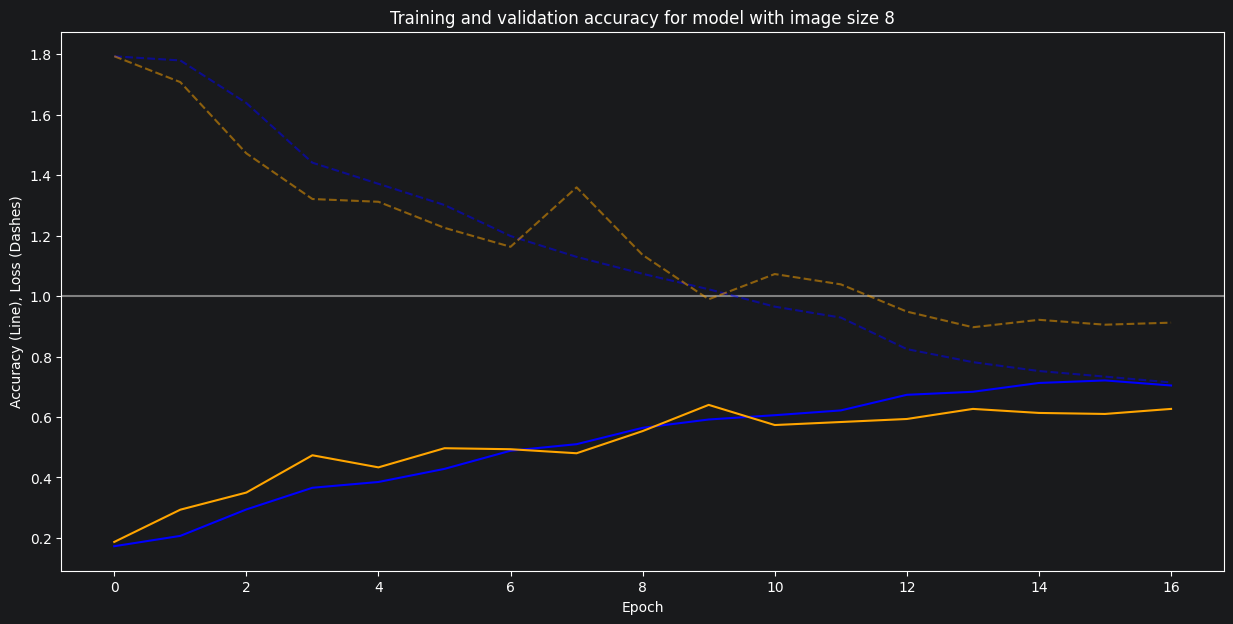

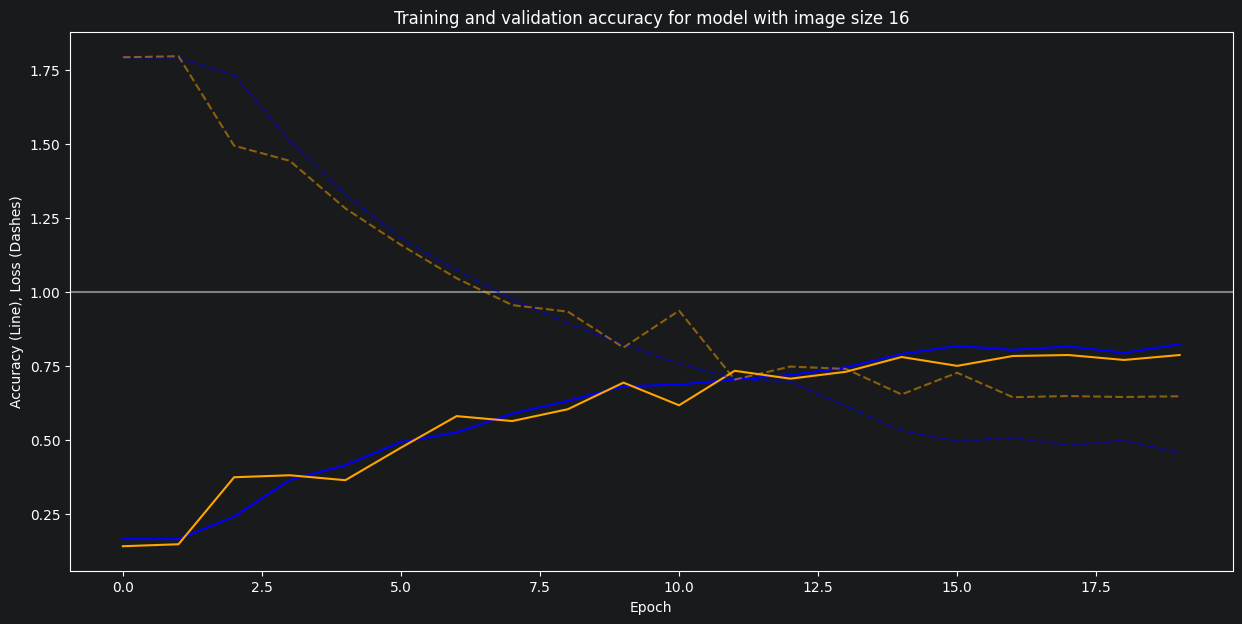

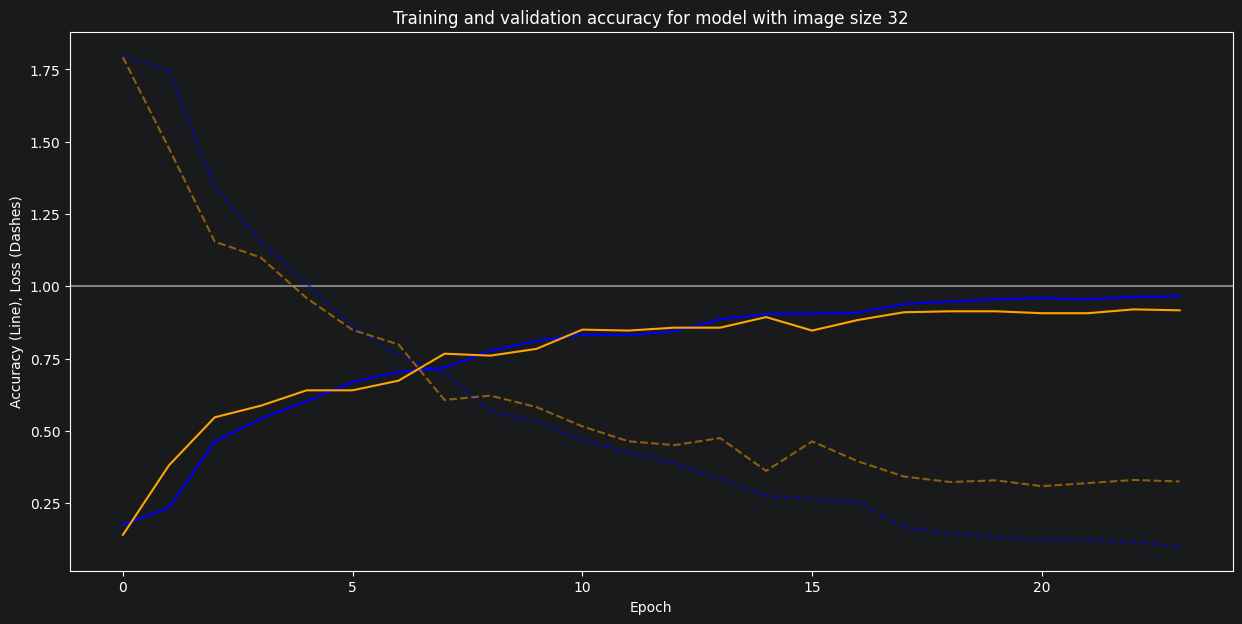

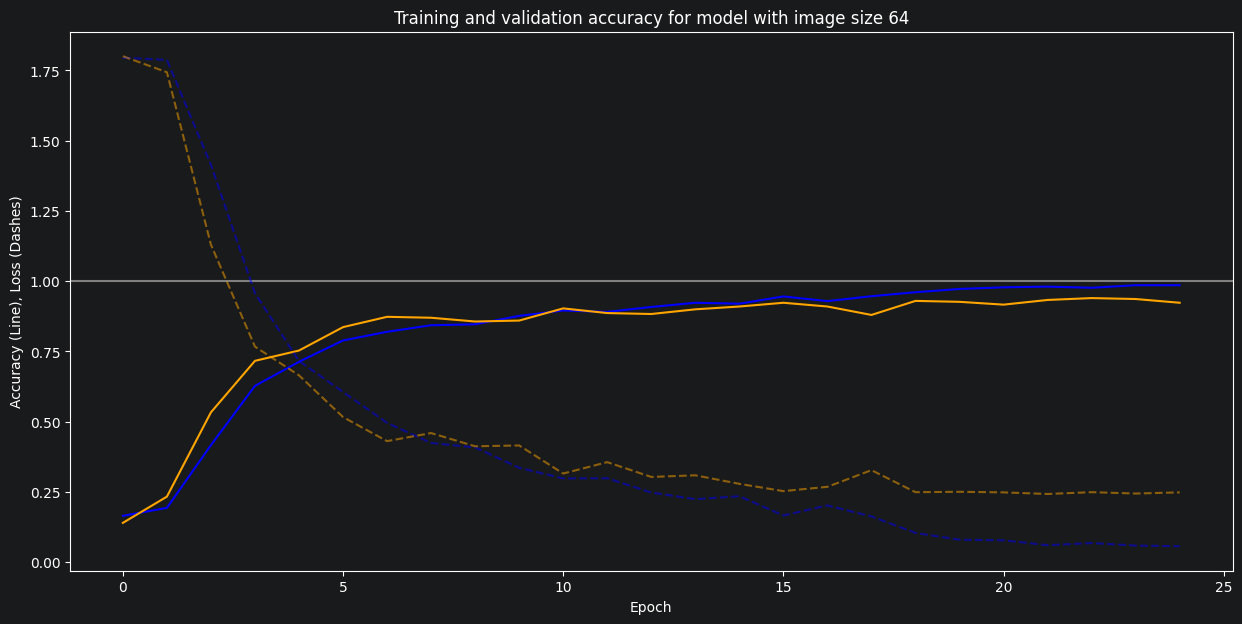

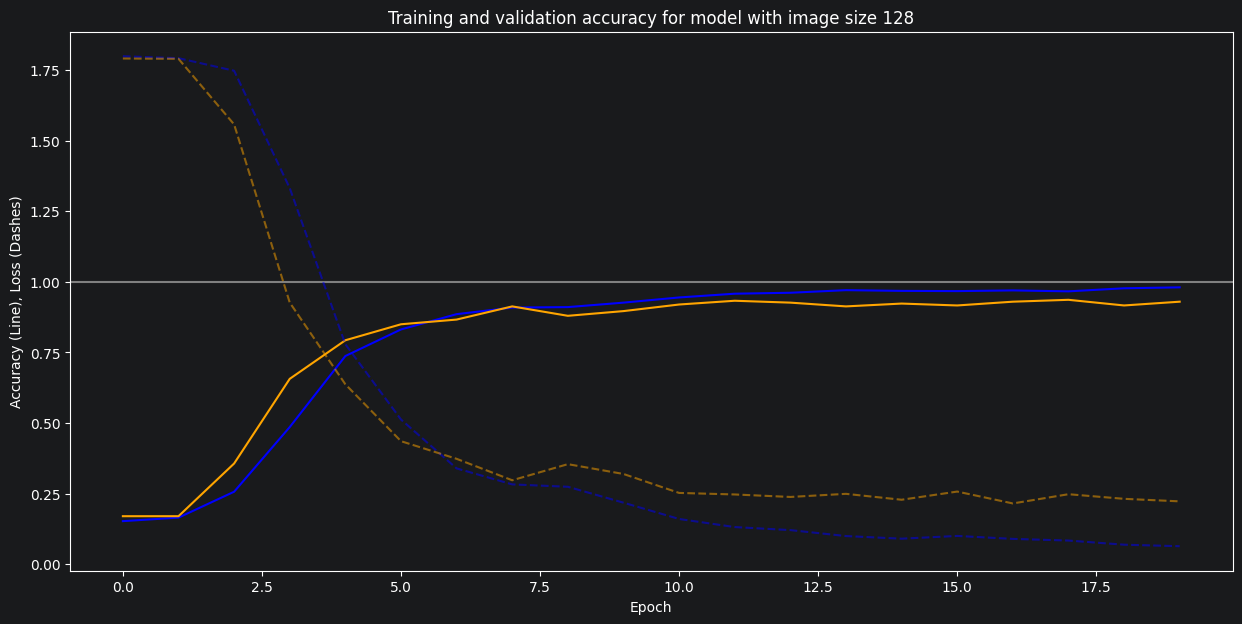

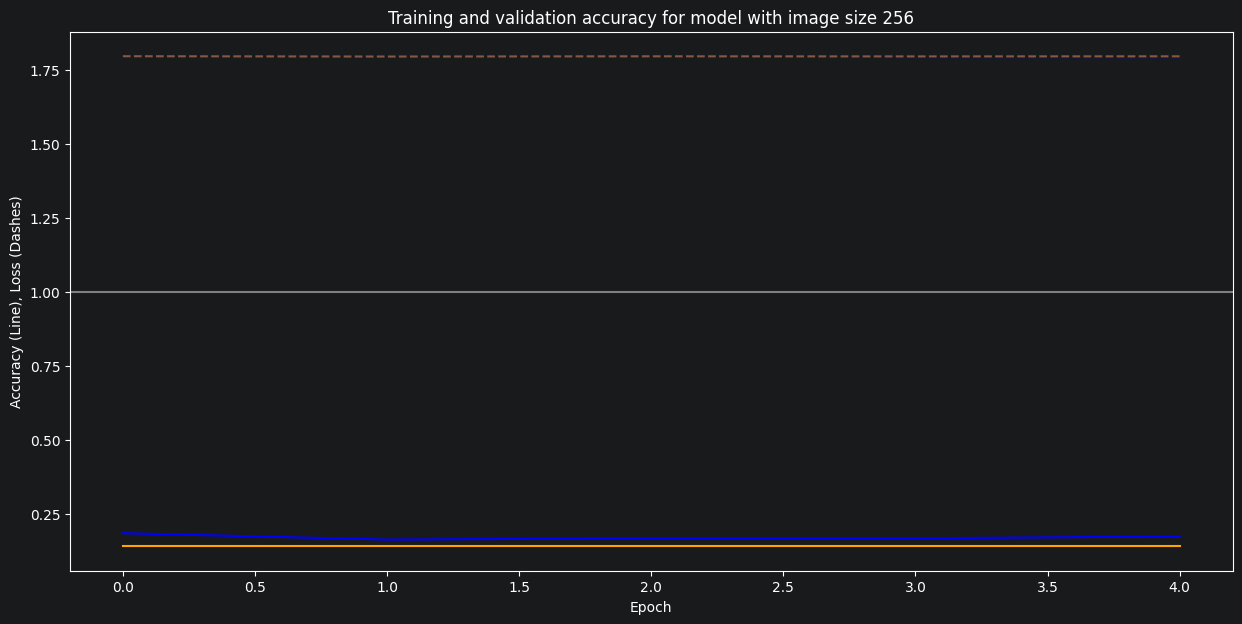

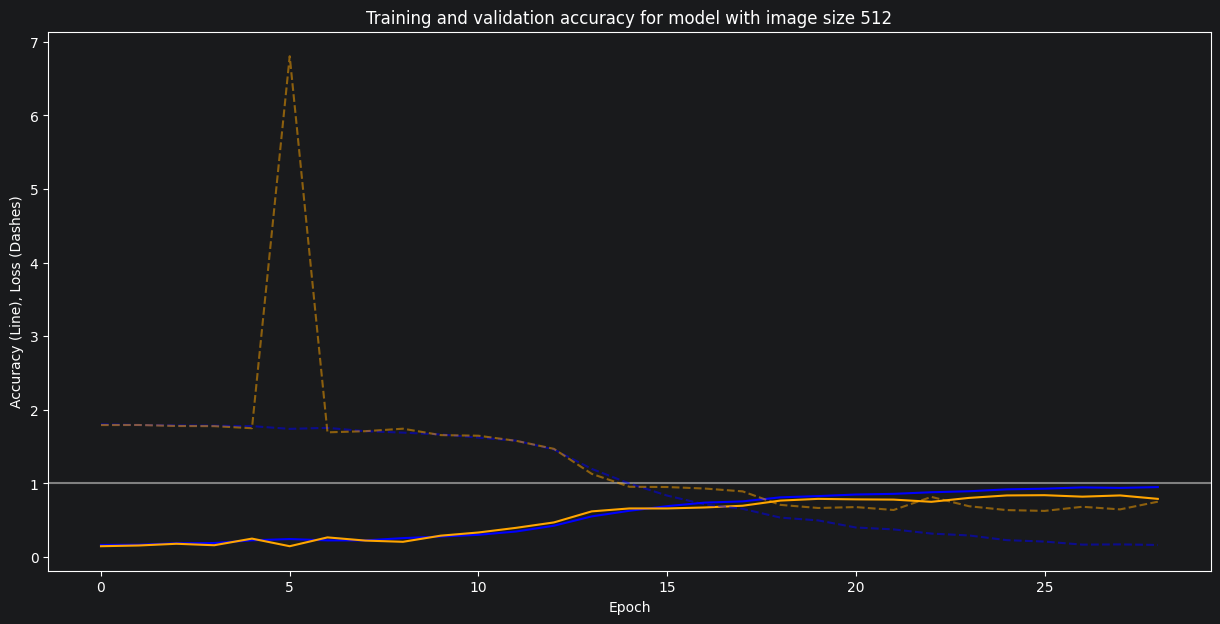

In [31]:
for size in IMG_SIZES:
    loss = histories[size].history['loss']
    val_loss = histories[size].history['val_loss']
    accuracy = histories[size].history['accuracy']
    val_accuracy = histories[size].history['val_accuracy']

    fig = plt.figure(figsize=(15, 7))
    ax = plt.gca()

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

    ax.axhline(1, color='gray')

    plt.title('Training and validation accuracy for model with image size {}'.format(size))
    plt.plot(accuracy, color='blue')
    plt.plot(val_accuracy, color='orange')
    plt.plot(loss, '--', color='blue', alpha=0.5)
    plt.plot(val_loss, '--', color='orange', alpha=0.5)
    plt.show()

## Saving for later

We can now save each model for later use

In [32]:
for size in IMG_SIZES:
    models[size].save(f'gesture_classifier_{size}.keras')
    label_string = ''
    with open(f'gesture_classifier_{size}_labels.txt', 'w') as f:
        f.write(','.join(label_names[size]))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 793ms/step


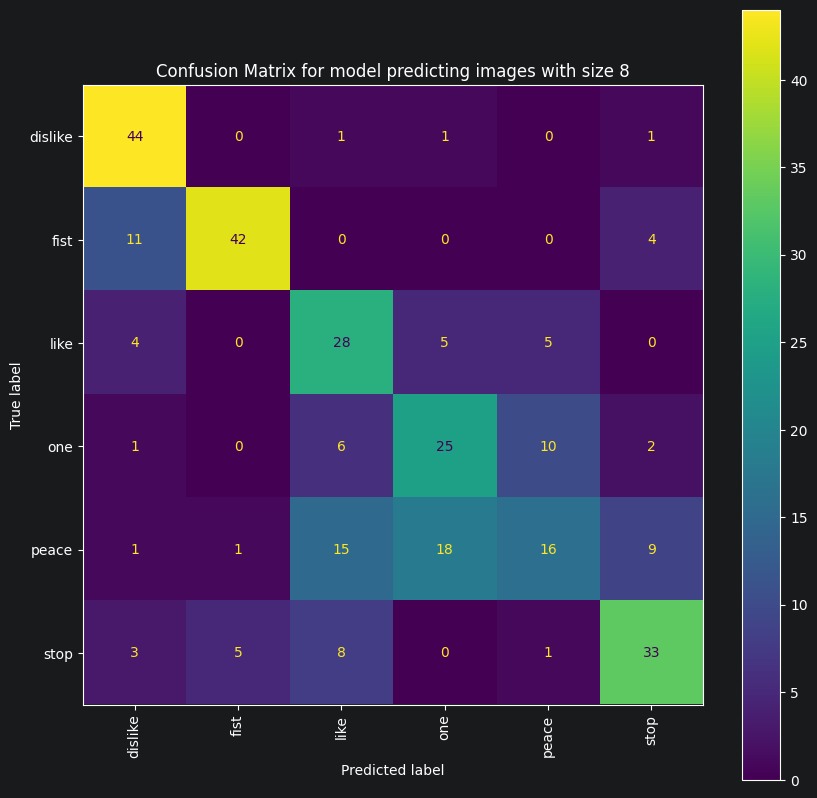

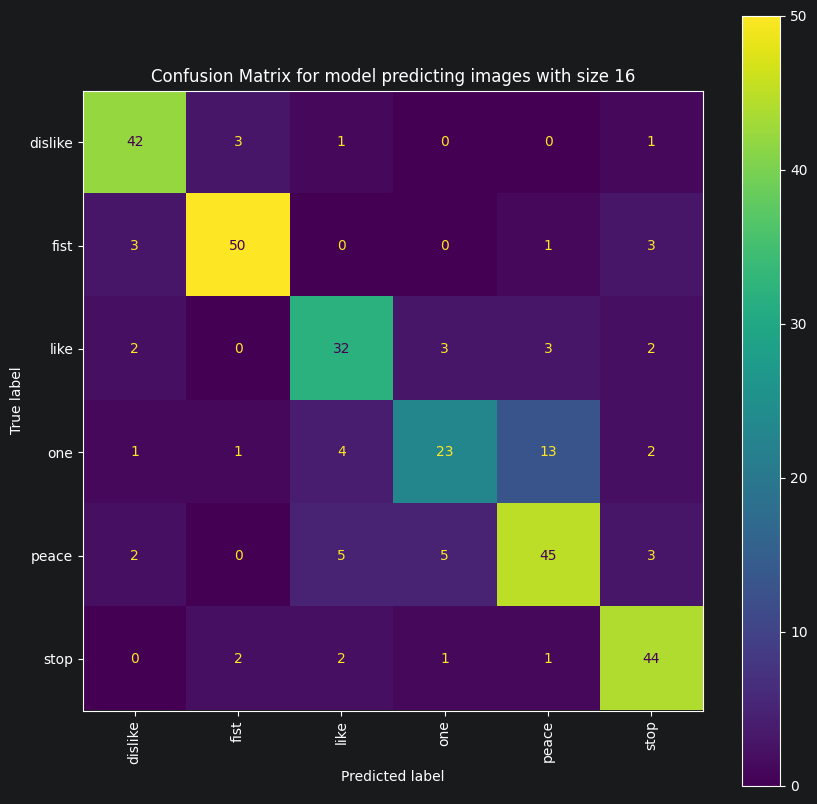

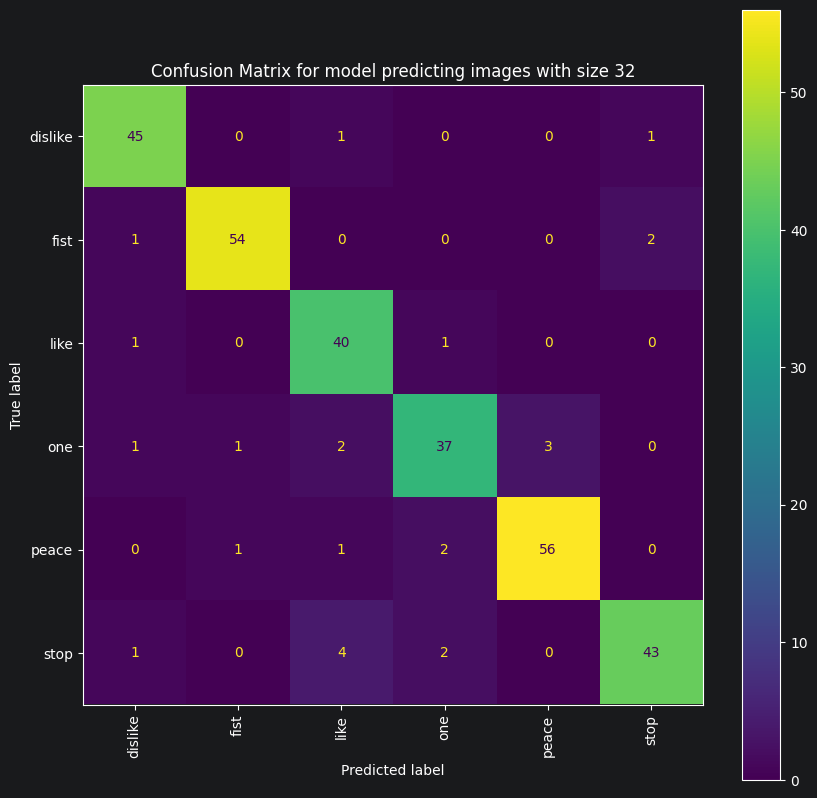

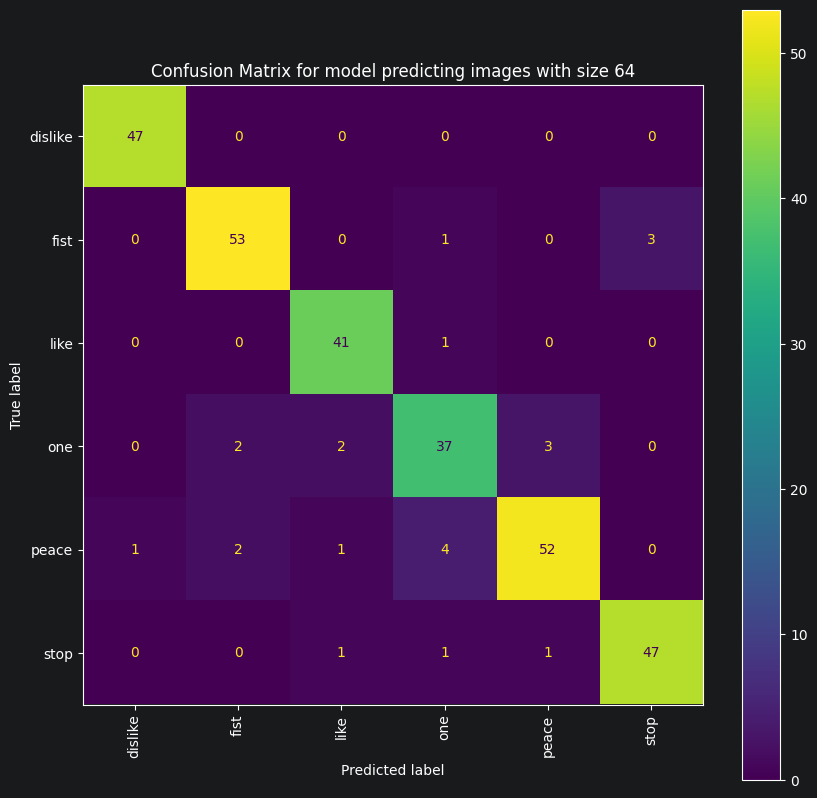

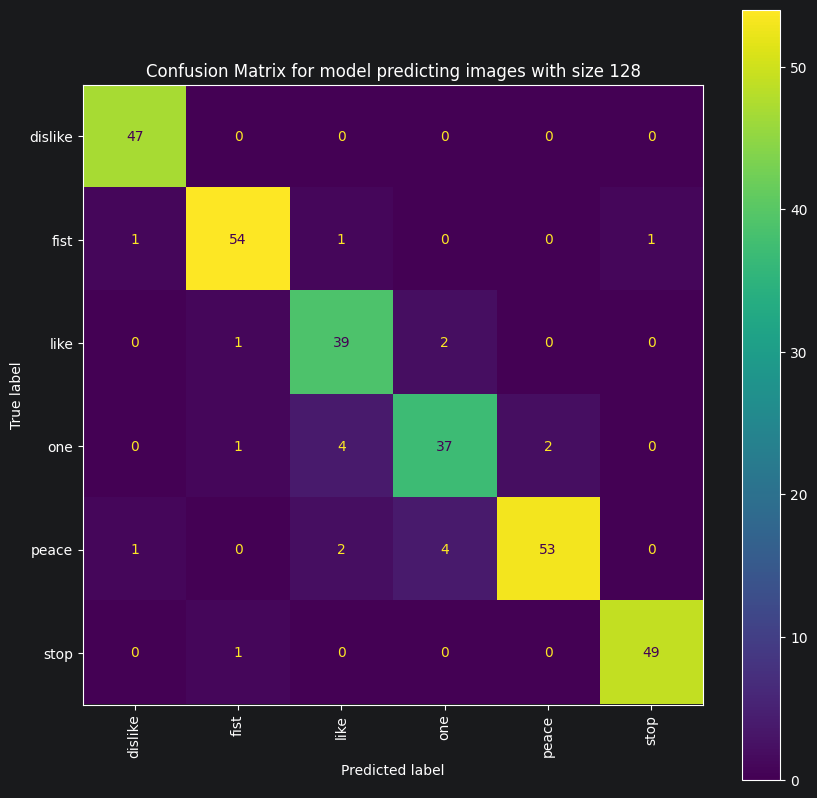

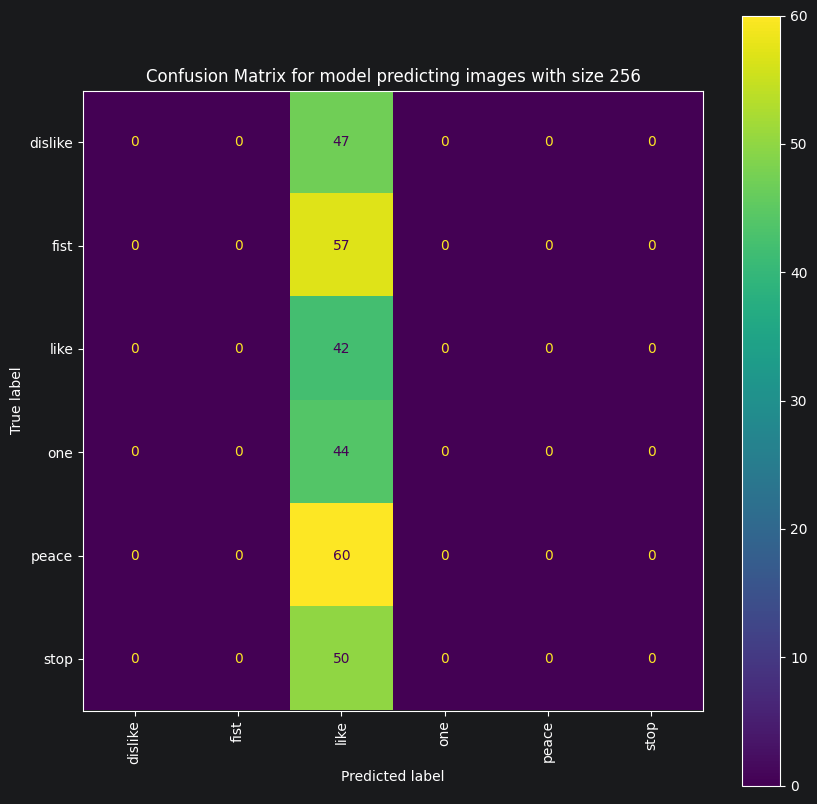

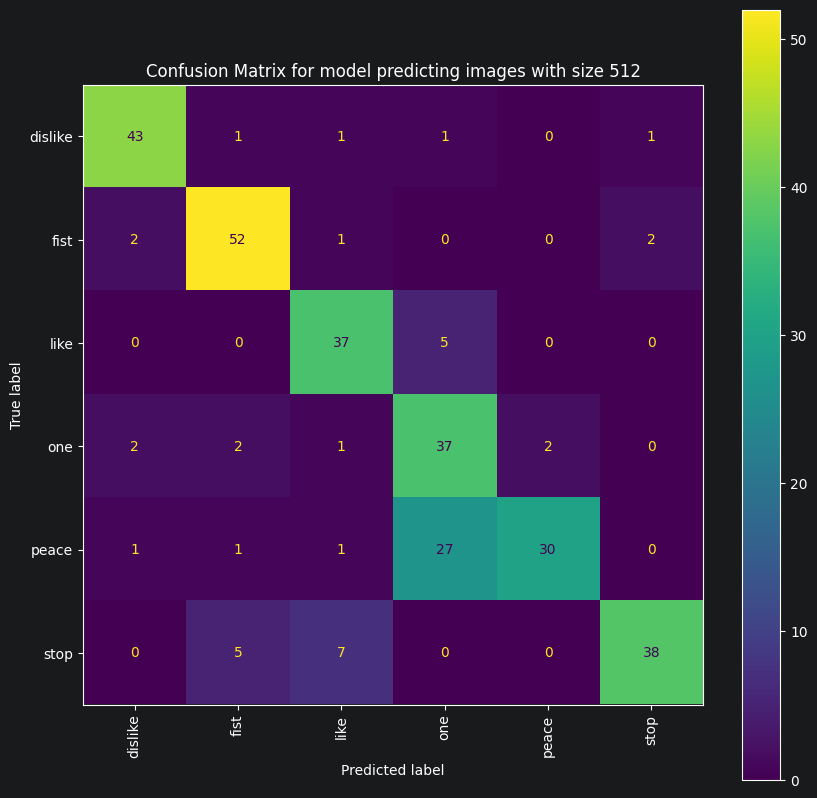

In [33]:
for size in IMG_SIZES:
    model = models[size]

    y_pred = model.predict(X_test[size])
    y_pred = np.argmax(y_pred, axis=1)


    conf_matrix = confusion_matrix(y_test[size], y_pred)

    fig = plt.figure(figsize=(10, 10))
    plt.title('Confusion Matrix for model predicting images with size {}'.format(size))
    ConfusionMatrixDisplay(conf_matrix, display_labels=label_names[size]).plot(ax=plt.gca())

    plt.xticks(rotation=90, ha='center')
    #plt.show()


## Some visualizations

We already know how long it took to train all these models, but why dont' we visulaize it

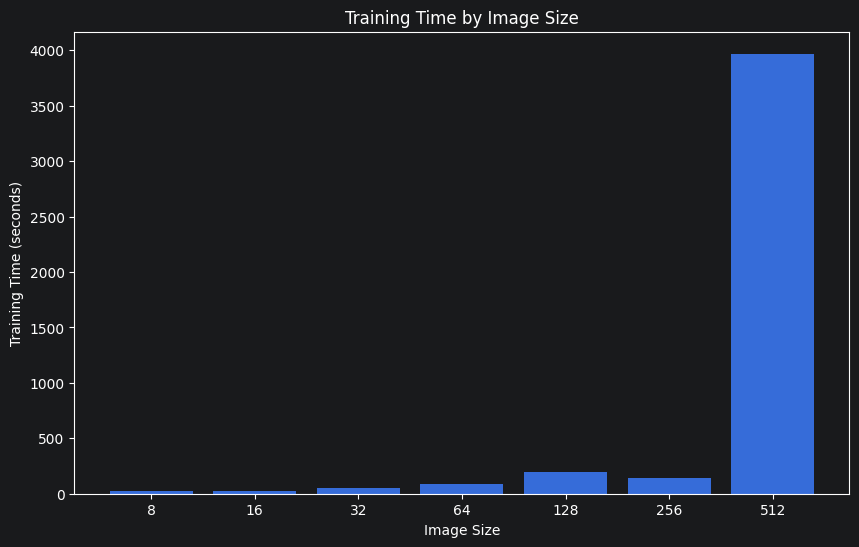

In [34]:
sizes = IMG_SIZES
training_times = [times[size] for size in sizes]

plt.figure(figsize=(10, 6))
plt.bar([str(size) for size in sizes], training_times)

plt.title('Training Time by Image Size')
plt.xlabel('Image Size')
plt.ylabel('Training Time (seconds)')

plt.show()

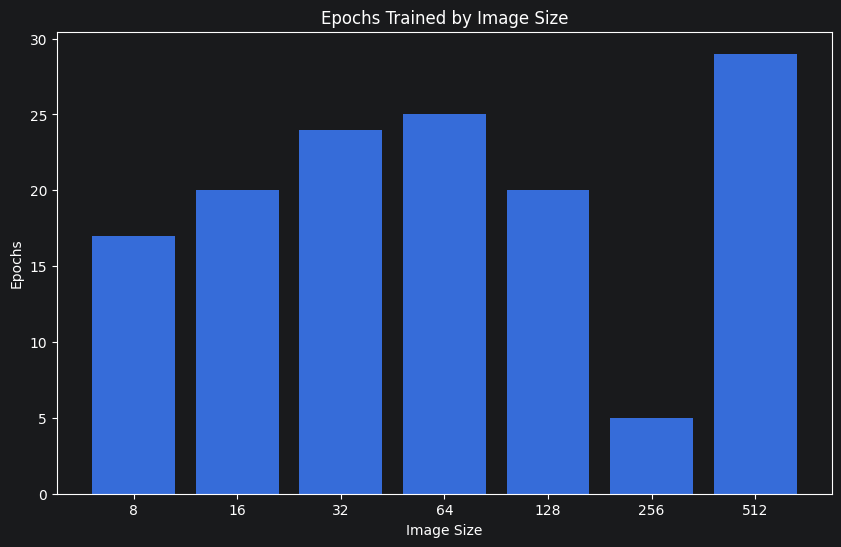

In [35]:
sizes = IMG_SIZES
epochs_trained = [
    len(histories[size].history['loss'])
    for size in sizes
]

plt.figure(figsize=(10, 6))
plt.bar([str(size) for size in sizes], epochs_trained)

plt.title('Epochs Trained by Image Size')
plt.xlabel('Image Size')
plt.ylabel('Epochs')

plt.show()

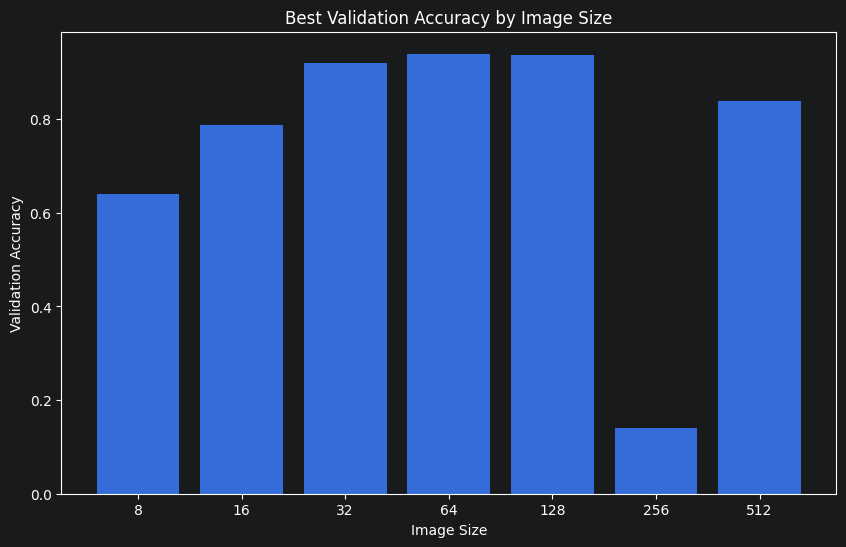

In [36]:
sizes = IMG_SIZES
best_val_acc = [
    max(histories[size].history['val_accuracy'])
    for size in sizes
]

plt.figure(figsize=(10, 6))
plt.bar([str(size) for size in sizes], best_val_acc)

plt.title('Best Validation Accuracy by Image Size')
plt.xlabel('Image Size')
plt.ylabel('Validation Accuracy')

plt.show()

## Conclusion

We can see an interesting trend right here. The image size of 32 performs best in terms of accuracy and took the most epochs to train. However, the time it took to train the 32 model was among the shortest times of all. It seems that 32 (in this case) hits a sweet spot where the information in the picture is clear enough to give good results but there is not enough data to make things noisy. Considering we trained until no improvements could be found within 3 epochs this is expected. Since we can predict gestures reliably, adding more data on top can hardly help in making things better and will only introduce noise at some point.

We can see that training time skyrocketed at the end for the 512 model, this is expected as this model has by far the most input points

model 8 took the most epochs to train. This can be an outlier due to 8 px containing so little info that it stays ambiguous for a long time. However this can not be generalized after such little experimentation and we would have to test this for more datasets etc.

